In [13]:
!pip install -qU pip setuptools wheel
!pip install -qU spacy
!pip install -qU googletrans==4.0.0-rc1
!python -m spacy download zh_core_web_sm
!python -m spacy download zh_core_web_md
!python -m spacy download zh_core_web_lg
!python -m spacy download zh_core_web_trf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.1/29.1 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.6.1 requires numpy<2.0a0,>=1.23, but you have numpy 2.0.2 which is incompatible.
cupy-cuda12x 12.2.0 requires numpy<1.27,>=1.20, but you have numpy 2.0.2 which is incompatible.
en-core-web-sm 3.7.1 requires spacy<3.8.0,>=3.7.2, but you have spacy 3.8.2 which is in

加載語言模型

In [15]:
import spacy

nlp_en = spacy.load("en_core_web_sm")
nlp_zh = spacy.load("zh_core_web_sm")

/usr/local/lib/python3.10/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'zh_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


句子

In [16]:
source_sentence = "張三在台北101前面拍了很多照片。"

翻譯

In [17]:
from googletrans import Translator
translator = Translator() # 翻譯器

current_translation = translator.translate(source_sentence, src = "zh-TW", dest='en')
transtext = current_translation.text

使用 spaCy 進行分詞

In [18]:
doc_zh = nlp_zh(source_sentence)
doc_en = nlp_en(transtext)

# 輸出分詞結果
tokens_zh = [token.text for token in doc_zh]
tokens_en = [token.text for token in doc_en]

print(tokens_zh)
print(tokens_en)

['張三', '在', '台北', '101', '前面', '拍', '了', '很多', '照片', '。']
['Zhang', 'San', 'took', 'a', 'lot', 'of', 'photos', 'in', 'front', 'of', 'Taipei', '101', '.']


處理一下專有名詞

In [19]:
# 中文的專有名詞
# 合併指定的詞組 (台北 101)
with doc_zh.retokenize() as retokenizer:
    for i, token in enumerate(doc_zh):
        if token.text == "台北" and doc_zh[i+1].text == "101":
            retokenizer.merge(doc_zh[i:i+2])

# 輸出中文分詞結果
tokens_zh = [token.text for token in doc_zh]
print(tokens_zh)

['張三', '在', '台北101', '前面', '拍', '了', '很多', '照片', '。']


In [20]:
# 英文的專有名詞
# 使用 spaCy 進行分詞和命名實體識別
doc_en = nlp_en(transtext)

# 將命名實體合併為一個 token
with doc_en.retokenize() as retokenizer:
    for ent in doc_en.ents:
        retokenizer.merge(ent)

# 輸出分詞結果
tokens_en = [token.text for token in doc_en]
print(tokens_en)

['Zhang San', 'took', 'a', 'lot', 'of', 'photos', 'in', 'front', 'of', 'Taipei', '101', '.']


##Word Alignment

### SimAlign

In [21]:
!pip install -qU simalign

In [22]:
from simalign import SentenceAligner

# 創建一個 SentenceAligner
aligner = SentenceAligner(model="bert", token_type="bpe", matching_methods="mai")

# 中英文句子
src_sent = "Zhang San took a lot of photos in front of Taipei 101."
tgt_sent = "張三在台北101前面拍了很多照片。"

# 生成詞對齊矩陣
alignments = aligner.get_word_aligns(src_sent, tgt_sent)

print(alignments)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
2024-10-08 03:28:54,295 - simalign.simalign - INFO - Initialized the EmbeddingLoader with model: bert-base-multilingual-cased
INFO:simalign.simalign:Initialized the EmbeddingLoader with model: bert-base-multilingual-cased


{'mwmf': [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0)], 'inter': [(0, 0), (1, 0), (2, 0), (4, 0), (5, 0), (6, 0), (9, 0), (10, 0), (11, 0)], 'itermax': [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0)]}


In [40]:
for method, aligns in alignments.items():
    print(f"# --- 對齊方法: {method} --- #")
    for pair in aligns:
        print(f"中文詞: {src_sent[pair[0]]} -> 英文詞: {tgt_sent[pair[1]]}")


# --- 對齊方法: mwmf --- #
中文詞: Z -> 英文詞: 張
中文詞: h -> 英文詞: 張
中文詞: a -> 英文詞: 張
中文詞: n -> 英文詞: 張
中文詞: g -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: S -> 英文詞: 張
中文詞: a -> 英文詞: 張
中文詞: n -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: t -> 英文詞: 張
中文詞: o -> 英文詞: 張
# --- 對齊方法: inter --- #
中文詞: Z -> 英文詞: 張
中文詞: h -> 英文詞: 張
中文詞: a -> 英文詞: 張
中文詞: g -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: S -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: t -> 英文詞: 張
中文詞: o -> 英文詞: 張
# --- 對齊方法: itermax --- #
中文詞: Z -> 英文詞: 張
中文詞: h -> 英文詞: 張
中文詞: a -> 英文詞: 張
中文詞: n -> 英文詞: 張
中文詞: g -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: S -> 英文詞: 張
中文詞: a -> 英文詞: 張
中文詞: n -> 英文詞: 張
中文詞:   -> 英文詞: 張
中文詞: t -> 英文詞: 張
中文詞: o -> 英文詞: 張


### eflomal

In [27]:
# Clone the Eflomal repository
!git clone https://github.com/robertostling/eflomal

# Move into the eflomal folder
%cd /content/eflomal

# Install Eflomal
!make
!sudo make install
!python3 setup.py install

fatal: destination path 'eflomal' already exists and is not an empty directory.
/content/eflomal
make: *** No targets specified and no makefile found.  Stop.
make: *** No rule to make target 'install'.  Stop.
Compiling python/eflomal/eflomal.pyx because it changed.
[1/1] Cythonizing python/eflomal/eflomal.pyx
/usr/local/lib/python3.10/dist-packages/setuptools/_distutils/dist.py:261: UserWarning: Unknown distribution option: 'tests_require'
  warnings.warn(msg)
/usr/local/lib/python3.10/dist-packages/setuptools/dist.py:294: InformationOnly: Normalizing '1.0.0-beta2' to '1.0.0b2'
  self.metadata.version = self._normalize_version(self.metadata.version)
running install
/usr/local/lib/python3.10/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installe

In [28]:
# 中英文雙語句子
src_text = "Zhang San took a lot of photos in front of Taipei 101."
tgt_text = "張三在台北101前面拍了很多照片。"

# 假設已經安裝好 eflomal 並使用進行詞對齊
with open('src.txt', 'w') as f:
    f.write(src_text)

with open('tgt.txt', 'w') as f:
    f.write(tgt_text)

In [34]:
!python3 /content/eflomal/python/scripts/eflomal-align -s "src.txt" -t "tgt.txt" --model 3 -f src-tgt.fwd -r src-tgt.rev


ERROR:__main__:output file src-tgt.fwd exists, will not overwrite!


In [35]:
!cat src-tgt.fwd

In [33]:
!cat src-tgt.rev

0-0 2-0 4-0


In [38]:
print(src_text)
print(tgt_text)

Zhang San took a lot of photos in front of Taipei 101.
張三在台北101前面拍了很多照片。


### fast_alignment

In [36]:
!sudo apt-get install libgoogle-perftools-dev libsparsehash-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libunwind-dev
The following NEW packages will be installed:
  libgoogle-perftools-dev libsparsehash-dev libunwind-dev
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 2,424 kB of archives.
After this operation, 10.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libunwind-dev amd64 1.3.2-2build2.1 [1,883 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libgoogle-perftools-dev amd64 2.9.1-0ubuntu3 [470 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libsparsehash-dev all 2.0.3-2 [71.7 kB]
Fetched 2,424 kB in 1s (2,903 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> l

In [37]:
!mkdir build
!cd build
!cmake ..
!make

mkdir: cannot create directory ‘build’: File exists
CMake Warning:
  Ignoring extra path from command line:

   ".."


CMake Error: The source directory "/content" does not appear to contain CMakeLists.txt.
Specify --help for usage, or press the help button on the CMake GUI.
make: *** No targets specified and no makefile found.  Stop.


### 讓 chatgpt-4o 幫我列出對應關係

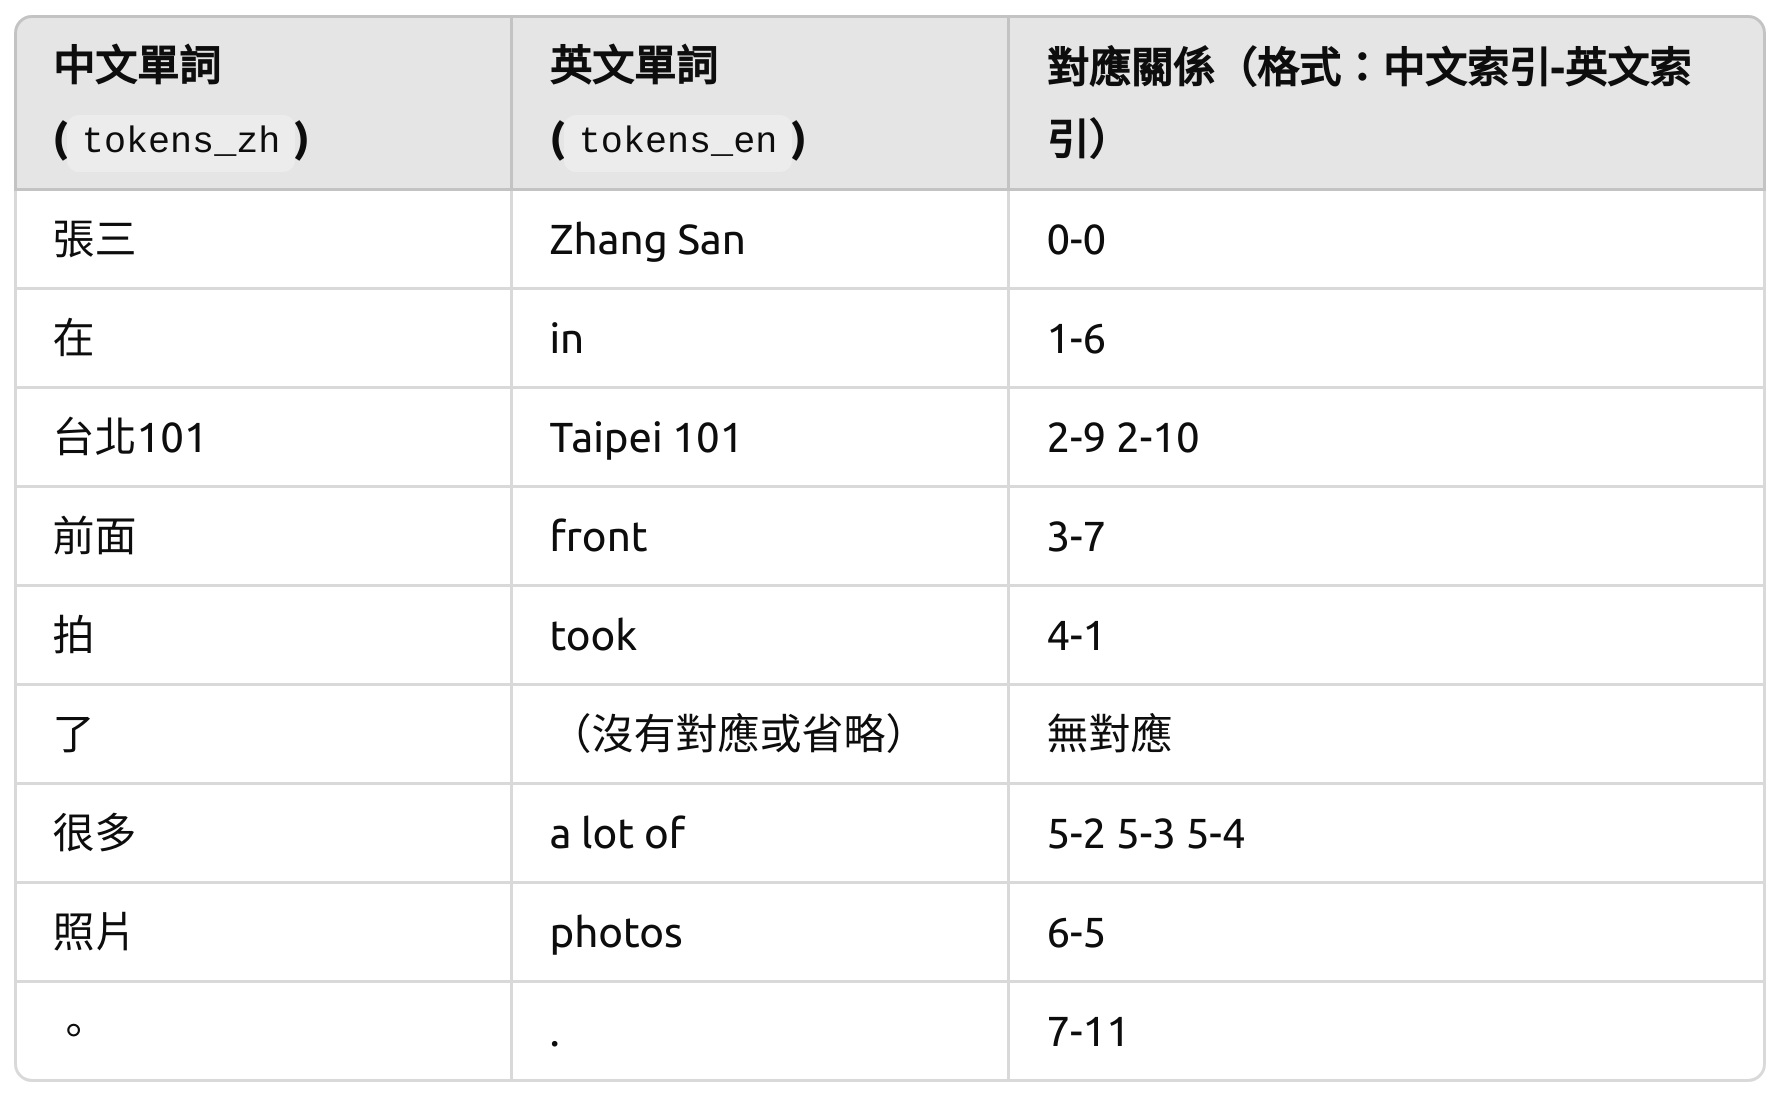

## 修正翻譯

In [45]:
# 中英文句子
src_sent = "Zhang San took a lot of photos in front of Taipei 101."
tgt_sent = "張三在台北101前面拍了很多照片。"

# 定義中文和英文的詞彙列表
tokens_zh = ['張三', '在', '台北101', '前面', '拍', '了', '很多', '照片', '。']
tokens_en = ['Zhang San', 'took', 'a', 'lot', 'of', 'photos', 'in', 'front', 'of', 'Taipei', '101', '.']

# 定義對應關係 (中文索引 -> 英文索引)
alignment = {
    0: [0],      # 張三 -> Zhang San
    1: [6],      # 在 -> in
    2: [9, 10],  # 台北101 -> Taipei 101
    3: [7],      # 前面 -> front
    4: [1],      # 拍 -> took
    5: [],       # 了 -> (無對應)
    6: [2, 3, 4],# 很多 -> a lot of
    7: [5],      # 照片 -> photos
    8: [11]      # 。 -> .
}

# 生成對齊格式的列表
alignment_list = []
alignment_word_list = []

for zh_idx, en_idxs in alignment.items():
    for en_idx in en_idxs:
        alignment_list.append(f"{zh_idx}-{en_idx}")
        alignment_word_list.append(f"{tokens_zh[zh_idx]}-{tokens_en[en_idx]}")

# 將對齊結果列出來
alignment_str = " ".join(alignment_list)
alignment_word_str = "\n".join(alignment_word_list)

print("對齊結果 (Pharaoh format):")
print(alignment_str)
print("-"*20)
print(alignment_word_str)


對齊結果 (Pharaoh format):
0-0 1-6 2-9 2-10 3-7 4-1 6-2 6-3 6-4 7-5 8-11
--------------------
張三-Zhang San
在-in
台北101-Taipei
台北101-101
前面-front
拍-took
很多-a
很多-lot
很多-of
照片-photos
。-.


# 修改流程

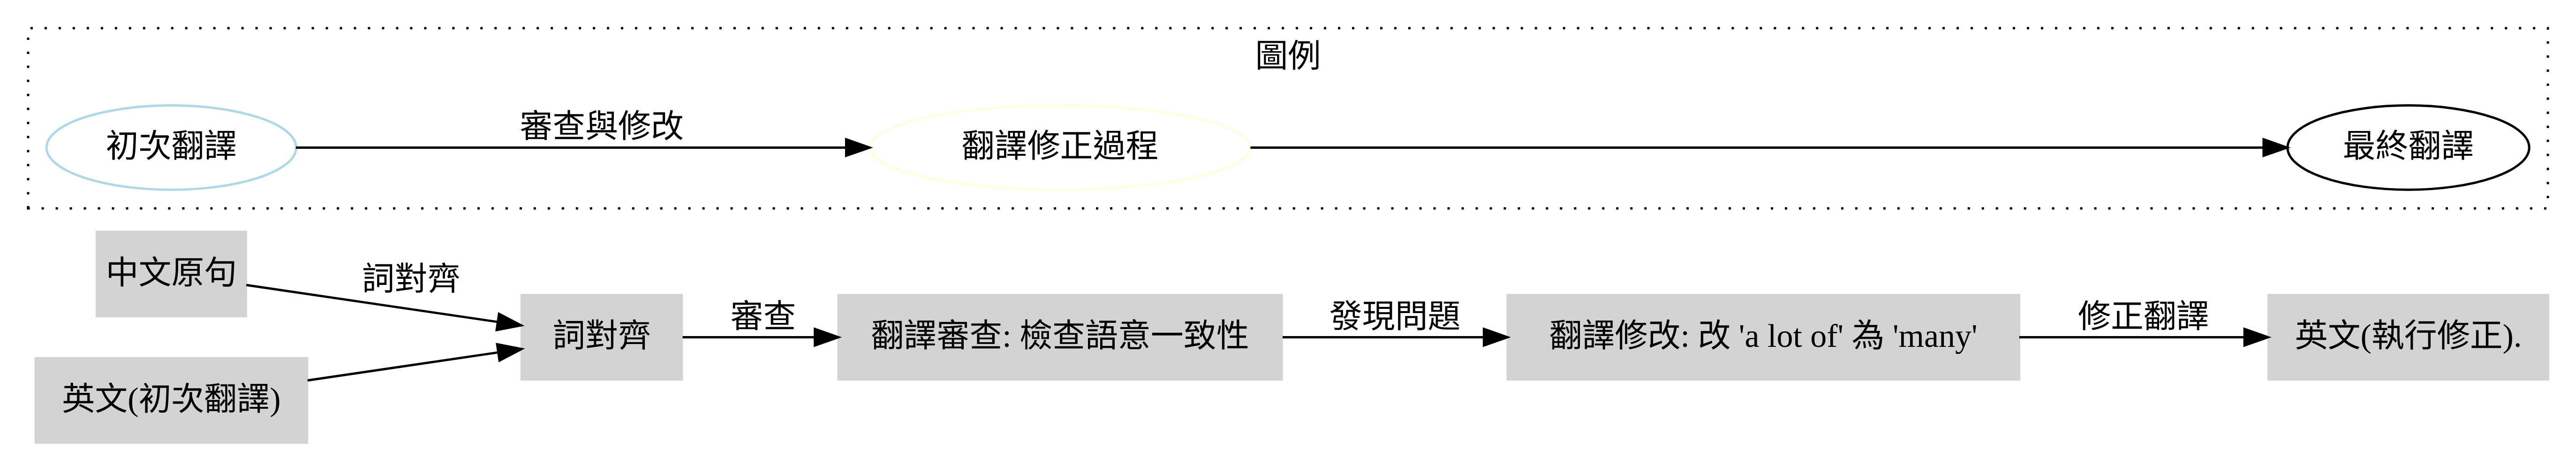

In [47]:
# 定義中文和英文的詞彙列表
tokens_zh = ['張三', '在', '台北101', '前面', '拍', '了', '很多', '照片', '。']
tokens_en_initial = ['Zhang San', 'took', 'a', 'lot', 'of', 'photos', 'in', 'front', 'of', 'Taipei', '101', '.']

# 規則: 檢查並修正翻譯
def review_and_correct_translation(tokens_en):
    # 把 tokens 轉換為句子
    initial_translation = " ".join(tokens_en)

    # 輸出初始翻譯
    print("初始翻譯: ", initial_translation)

    # 修正邏輯: 將 "a lot of" 改為 "many"
    if "a lot of" in initial_translation:
        corrected_translation = initial_translation.replace("a lot of", "many")
        print("修正後的翻譯: ", corrected_translation)
    else:
        corrected_translation = initial_translation

    return corrected_translation

# 執行翻譯審查與修正
corrected_translation = review_and_correct_translation(tokens_en_initial)

# 結果展示
print("\n=== 翻譯修正流程 ===")
print("初始翻譯: " + " ".join(tokens_en_initial))
print("修正後翻譯: " + corrected_translation)


初始翻譯:  Zhang San took a lot of photos in front of Taipei 101 .
修正後的翻譯:  Zhang San took many photos in front of Taipei 101 .

=== 翻譯修正流程 ===
初始翻譯: Zhang San took a lot of photos in front of Taipei 101 .
修正後翻譯: Zhang San took many photos in front of Taipei 101 .
